## Cell 1 — Install & Import Libraries

In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '  No GPU detected — change runtime type to GPU!')

import os, shutil, random, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split

print(f' TensorFlow version: {tf.__version__}')
print(f' GPU devices: {tf.config.list_physical_devices("GPU")}')

Thu Apr 23 15:32:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print(' Google Drive mounted at /content/drive')

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


## Cell 3 — Configuration  
⚙️ **Edit `DATASET_PATH`** to point at your Drive folder (the one containing `bud_rot/`, `healthy/`, etc.).

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  EDIT THIS PATH to match your Google Drive folder structure
#  Example: '/content/drive/MyDrive/dataset/dataset'
DATASET_PATH = '/content/drive/MyDrive/dataset/dataset'
# ═══════════════════════════════════════════════════════════════════════════

# Output paths (auto-created)
OUTPUT_DIR        = '/content/drive/MyDrive/coconut_model_output'
SPLIT_DATA_DIR    = '/content/split_data'
CHECKPOINT_PATH   = os.path.join(OUTPUT_DIR, 'best_model.keras')
TFLITE_PATH       = os.path.join(OUTPUT_DIR, 'coconut_disease_model.tflite')
TFLITE_QUANT_PATH = os.path.join(OUTPUT_DIR, 'coconut_disease_model_quantized.tflite')
LABELS_PATH       = os.path.join(OUTPUT_DIR, 'labels.txt')
HISTORY_PATH      = os.path.join(OUTPUT_DIR, 'training_history.json')

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_FROZEN = 15
EPOCHS_FINETUNE = 20
LR_FROZEN     = 1e-3
LR_FINETUNE   = 1e-5
SEED          = 42
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15

CLASS_NAMES   = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES   = len(CLASS_NAMES)

print(f' Dataset path  : {DATASET_PATH}')
print(f' Output dir    : {OUTPUT_DIR}')
print(f'  Classes ({NUM_CLASSES}) : {CLASS_NAMES}')

📂 Dataset path  : /content/drive/MyDrive/dataset/dataset
💾 Output dir    : /content/drive/MyDrive/coconut_model_output
🏷️  Classes (5) : ['bud_rot', 'healthy', 'leaf_spot', 'lethal_yellowing', 'root_wilt']


## Cell 4 — Dataset Inspection


📊 Total images: 2185

Class                   Count    Share
────────────────────────────────────────
bud_rot                    57   
healthy                   504   ██████
leaf_spot                 624   ████████
lethal_yellowing          500   ██████
root_wilt                 500   ██████


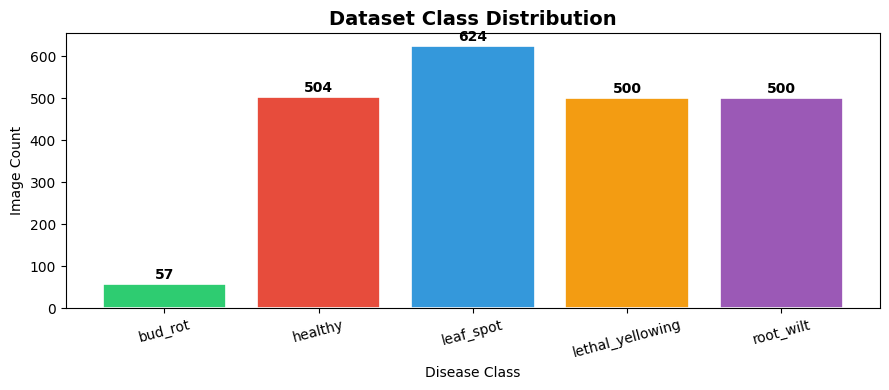

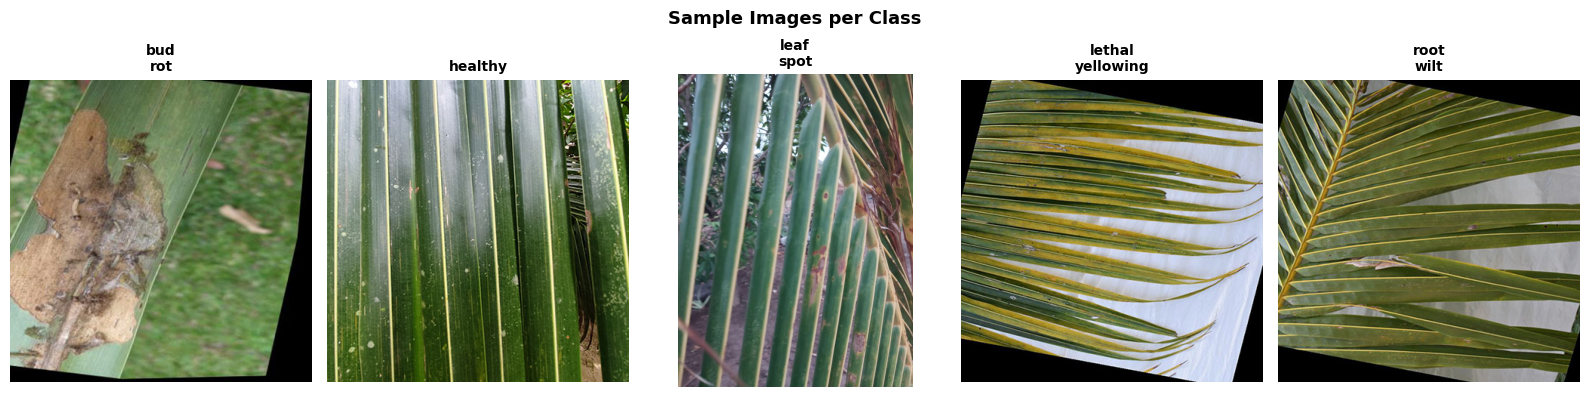

In [4]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

class_counts = {}
all_image_paths, all_labels = [], []

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_dir):
        print(f'⚠️  Skipping non-directory: {cls}')
        continue
    imgs = [f for f in os.listdir(cls_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]
    class_counts[cls] = len(imgs)
    for img in imgs:
        all_image_paths.append(os.path.join(cls_dir, img))
        all_labels.append(cls)

total = sum(class_counts.values())
print(f'\n📊 Total images: {total}\n')
print(f'{"Class":<20} {"Count":>8} {"Share":>8}')
print('─' * 40)
for cls, cnt in class_counts.items():
    bar = '█' * int(cnt / total * 30)
    print(f'{cls:<20} {cnt:>8}   {bar}')

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=colors[:NUM_CLASSES], edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(v), ha='center', va='bottom', fontweight='bold')
ax.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Image Count')
ax.set_xlabel('Disease Class')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

# ── Sample images ─────────────────────────────────────────────────────────
from PIL import Image
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_dir = os.path.join(DATASET_PATH, cls)
    sample = random.choice([f for f in os.listdir(cls_dir)
                            if os.path.splitext(f)[1].lower() in VALID_EXTS])
    img = Image.open(os.path.join(cls_dir, sample)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.replace('_', '\n'), fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=150)
plt.show()

## Cell 5 — Train / Validation / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    all_image_paths, all_labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    stratify=all_labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp, random_state=SEED
)

print(f'Train : {len(X_train)} images')
print(f'Val   : {len(X_val)} images')
print(f'Test  : {len(X_test)} images')

for split_name, paths, labels in [
        ('train', X_train, y_train),
        ('val',   X_val,   y_val),
        ('test',  X_test,  y_test)
]:
    for src, lbl in zip(paths, labels):
        dst_dir = os.path.join(SPLIT_DATA_DIR, split_name, lbl)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(src, dst_dir)

print('\n Data split and copied successfully.')

Train : 1529 images
Val   : 328 images
Test  : 328 images

✅ Data split and copied successfully.


## Cell 6 — Data Generators with Augmentation

In [6]:
# ── Training augmentation ────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.75, 1.25],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DATA_DIR, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DATA_DIR, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DATA_DIR, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_INDICES = train_gen.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}
print('Class indices:', CLASS_INDICES)

with open(LABELS_PATH, 'w') as f:
    for i in range(NUM_CLASSES):
        f.write(IDX_TO_CLASS[i] + '\n')
print(f'\n labels.txt saved → {LABELS_PATH}')

from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {CLASS_INDICES[cls]: w
                 for cls, w in zip(np.unique(y_train), class_weights_arr)}
print('\nClass weights:', class_weights)

Found 1529 images belonging to 5 classes.
Found 328 images belonging to 5 classes.
Found 328 images belonging to 5 classes.
Class indices: {'bud_rot': 0, 'healthy': 1, 'leaf_spot': 2, 'lethal_yellowing': 3, 'root_wilt': 4}

✅ labels.txt saved → /content/drive/MyDrive/coconut_model_output/labels.txt

Class weights: {0: np.float64(7.645), 1: np.float64(0.8662889518413598), 2: np.float64(0.7013761467889909), 3: np.float64(0.8737142857142857), 4: np.float64(0.8737142857142857)}


## Cell 7 — Build the Model (MobileNetV2 + Custom Head)

In [7]:
tf.random.set_seed(SEED)

# ── Base model ───────────────────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='CoconutDiseaseDetector')

model.compile(
    optimizer=keras.optimizers.Adam(LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nTrainable params (Phase 1): {model.trainable_variables.__len__()}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CoconutDiseaseDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,581 (10.01 MB)

 Trainable params: 364,037 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable params (Phase 1): 8


## Cell 8 — Phase 1: Train the Custom Head (Base Frozen)

In [8]:
cb_checkpoint = callbacks.ModelCheckpoint(
    CHECKPOINT_PATH, monitor='val_accuracy',
    save_best_only=True, verbose=1
)
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)
cb_lr_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-7, verbose=1
)

print('Phase 1 — Training custom head (base frozen)...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weights,
    callbacks=[cb_checkpoint, cb_early_stop, cb_lr_reduce],
    verbose=1
)

print(f'\n Phase 1 complete. Best val accuracy: '
      f'{max(history1.history["val_accuracy"]):.4f}')

🚀 Phase 1 — Training custom head (base frozen)...
Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.5596 - loss: 1.3136
Epoch 1: val_accuracy improved from None to 0.84146, saving model to /content/drive/MyDrive/coconut_model_output/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/coconut_model_output/best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7096 - loss: 0.8119 - val_accuracy: 0.8415 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.8717 - loss: 0.3756
Epoch 2: val_accuracy improved from 0.84146 to 0.94512, saving model to /content/drive/MyDrive/coconut_model_output/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/coconut_model_output/best_model.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 32s 673ms/step - accuracy: 0.8725 - loss: 0.3588 - val_accuracy: 0.9451 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6

## Cell 9 — Phase 2: Fine-tune Top Layers of MobileNetV2

In [9]:
base_model.trainable = True
UNFREEZE_FROM = len(base_model.layers) - 40
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfreezing top {trainable_count} layers of MobileNetV2 for fine-tuning')

model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset()
val_gen.reset()

print(' Phase 2 — Fine-tuning top MobileNetV2 layers...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weights,
    callbacks=[cb_checkpoint, cb_early_stop, cb_lr_reduce],
    verbose=1
)
print(f'\n✅ Phase 2 complete. Best val accuracy: '
      f'{max(history2.history["val_accuracy"]):.4f}')

Unfreezing top 40 layers of MobileNetV2 for fine-tuning
🚀 Phase 2 — Fine-tuning top MobileNetV2 layers...
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.8031 - loss: 0.6189
Epoch 1: val_accuracy did not improve from 0.98780
48/48 ━━━━━━━━━━━━━━━━━━━━ 69s 977ms/step - accuracy: 0.8241 - loss: 0.5680 - val_accuracy: 0.9726 - val_loss: 0.1252 - learning_rate: 1.0000e-05
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8697 - loss: 0.4085
Epoch 2: val_accuracy did not improve from 0.98780
48/48 ━━━━━━━━━━━━━━━━━━━━ 29s 605ms/step - accuracy: 0.8784 - loss: 0.3863 - val_accuracy: 0.9726 - val_loss: 0.1385 - learning_rate: 1.0000e-05
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.8800 - loss: 0.3701
Epoch 3: val_accuracy did not improve from 0.98780

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 642ms/step - accuracy: 0.8738 - loss: 0.3663 - val_accuracy: 0.9726 - val_loss: 0.1

## Cell 10 — Training Curves

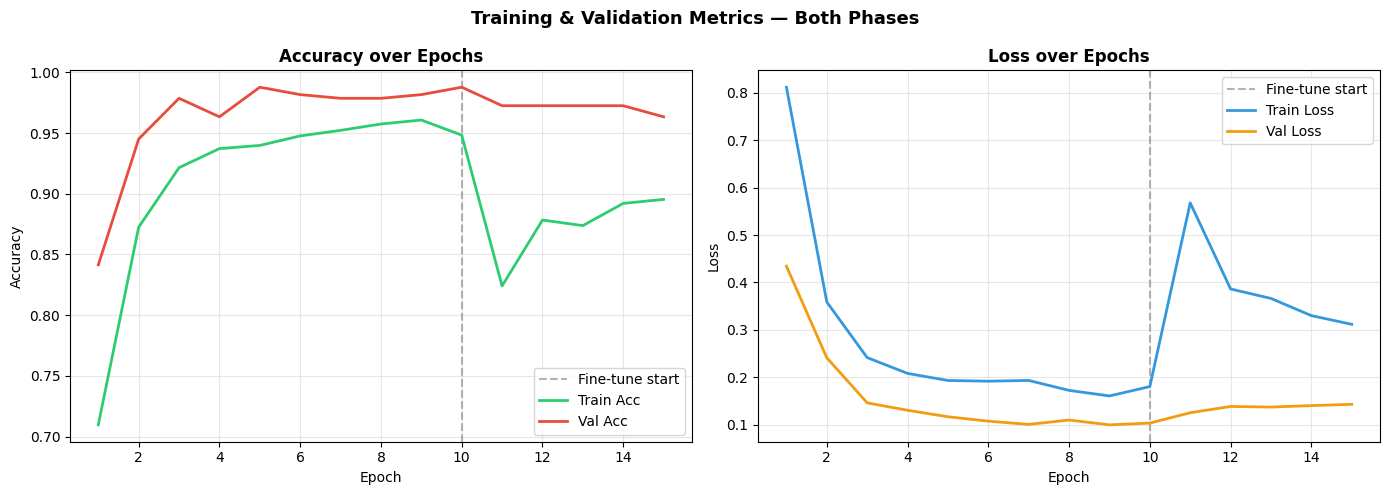

✅ History saved → /content/drive/MyDrive/coconut_model_output/training_history.json


In [10]:
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
total_epochs = list(range(1, len(acc) + 1))
phase2_start = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax in (ax1, ax2):
    ax.axvline(x=phase2_start, color='gray', linestyle='--', alpha=0.6,
               label='Fine-tune start')

ax1.plot(total_epochs, acc,     label='Train Acc', color='#2ecc71', linewidth=2)
ax1.plot(total_epochs, val_acc, label='Val Acc',   color='#e74c3c', linewidth=2)
ax1.set_title('Accuracy over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(total_epochs, loss,     label='Train Loss', color='#3498db', linewidth=2)
ax2.plot(total_epochs, val_loss, label='Val Loss',   color='#f39c12', linewidth=2)
ax2.set_title('Loss over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training & Validation Metrics — Both Phases', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

combined = {'accuracy': acc, 'val_accuracy': val_acc,
            'loss': loss, 'val_loss': val_loss}
with open(HISTORY_PATH, 'w') as f:
    json.dump(combined, f)
print(f'✅ History saved → {HISTORY_PATH}')

## Cell 11 — Evaluate on Test Set

✅ Best model loaded.
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 680ms/step

  TEST ACCURACY : 98.17%
  WEIGHTED F1   : 98.17%

📋 Per-class report:
                  precision    recall  f1-score   support

         bud_rot       1.00      1.00      1.00         9
         healthy       1.00      1.00      1.00        75
       leaf_spot       1.00      1.00      1.00        94
lethal_yellowing       0.97      0.95      0.96        75
       root_wilt       0.95      0.97      0.96        75

        accuracy                           0.98       328
       macro avg       0.98      0.98      0.98       328
    weighted avg       0.98      0.98      0.98       328



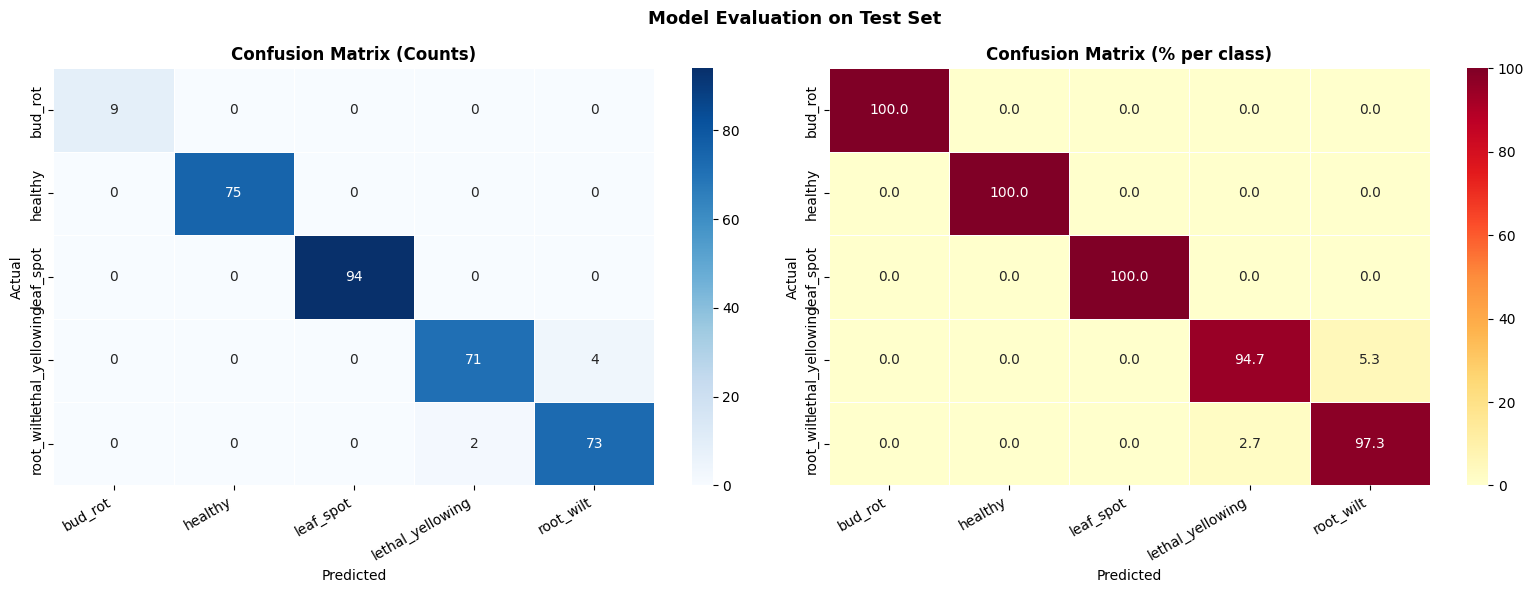


🎯 Target met! Accuracy 98.17% ≥ 85%


In [11]:
model = keras.models.load_model(CHECKPOINT_PATH)
print('✅ Best model loaded.')

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes
target_names = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]

test_acc = accuracy_score(y_true, y_pred)
test_f1  = f1_score(y_true, y_pred, average='weighted')

print(f'\n{'='*50}')
print(f'  TEST ACCURACY : {test_acc*100:.2f}%')
print(f'  WEIGHTED F1   : {test_f1*100:.2f}%')
print(f'{'='*50}')
print(f'\n📋 Per-class report:')
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix (% per class)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Model Evaluation on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

if test_acc >= 0.85:
    print(f'\n🎯 Target met! Accuracy {test_acc*100:.2f}% ≥ 85%')
else:
    print(f'\n⚠️  Accuracy {test_acc*100:.2f}% is below 85% target. See Cell 13 for tips.')

## Cell 12 — Per-Class Accuracy Bar Chart

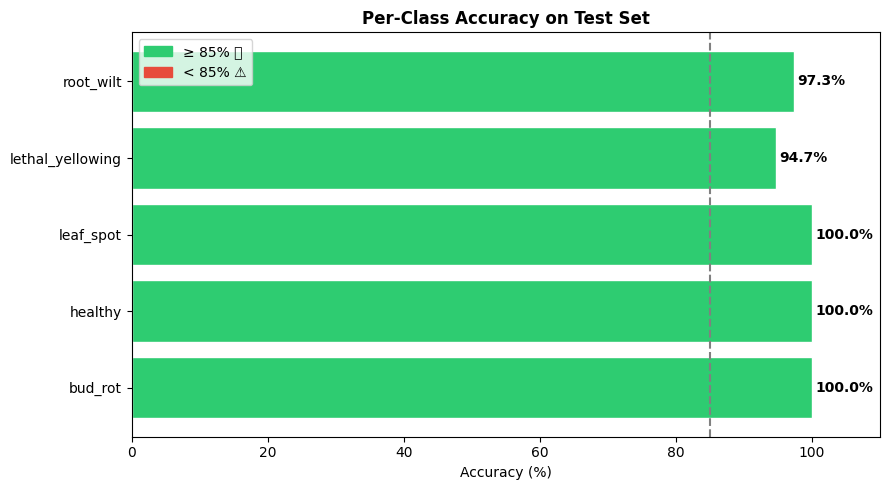

In [12]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#2ecc71' if v >= 85 else '#e74c3c' for v in per_class_acc]
bars = ax.barh(target_names, per_class_acc, color=colors_bar,
               edgecolor='white', linewidth=1)
ax.axvline(x=85, color='gray', linestyle='--', linewidth=1.5, label='85% target')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlim(0, 110)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy on Test Set', fontweight='bold')
ax.legend()
green_patch = mpatches.Patch(color='#2ecc71', label='≥ 85% ✅')
red_patch   = mpatches.Patch(color='#e74c3c', label='< 85% ⚠️')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_accuracy.png'), dpi=150)
plt.show()

## Cell 13 — Convert to TensorFlow Lite (Float32 + INT8 Quantized)

In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
size_mb = os.path.getsize(TFLITE_PATH) / 1024**2
print(f'✅ Float32 TFLite saved → {TFLITE_PATH}  ({size_mb:.2f} MB)')

converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter_q.convert()
with open(TFLITE_QUANT_PATH, 'wb') as f:
    f.write(tflite_quant_model)
size_q_mb = os.path.getsize(TFLITE_QUANT_PATH) / 1024**2
print(f'✅ Quantized TFLite saved → {TFLITE_QUANT_PATH}  ({size_q_mb:.2f} MB)')
print(f'   Size reduction: {(1 - size_q_mb/size_mb)*100:.1f}%')

Saved artifact at '/tmp/tmpjp3rqbhh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139477998823632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174673232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174683024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139477998821328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174668816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174683792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174667856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174683216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174683408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139476174683984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1394761746828

## Cell 14 — Verify TFLite Model (Sanity Check)

In [14]:
from PIL import Image
import numpy as np

def predict_with_tflite(tflite_path, image_path):
    """Run inference with a TFLite model on a single image."""
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    in_details  = interpreter.get_input_details()
    out_details = interpreter.get_output_details()

    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    interpreter.set_tensor(in_details[0]['index'], arr)
    interpreter.invoke()
    probs = interpreter.get_tensor(out_details[0]['index'])[0]
    return probs

print(' TFLite verification — one image per class:\n')
for cls in CLASS_NAMES:
    cls_dir = os.path.join(SPLIT_DATA_DIR, 'test', cls)
    if not os.path.exists(cls_dir):
        continue
    imgs = os.listdir(cls_dir)
    if not imgs:
        continue
    img_path = os.path.join(cls_dir, imgs[0])
    probs = predict_with_tflite(TFLITE_PATH, img_path)
    pred_idx   = np.argmax(probs)
    pred_class = IDX_TO_CLASS[pred_idx]
    confidence = probs[pred_idx] * 100
    status = '✅' if pred_class == cls else '❌'
    print(f'  {status}  True: {cls:<20} Predicted: {pred_class:<20}  Confidence: {confidence:.1f}%')

print('\n TFLite model verification complete.')

🔍 TFLite verification — one image per class:

  ✅  True: bud_rot              Predicted: bud_rot               Confidence: 100.0%
  ✅  True: healthy              Predicted: healthy               Confidence: 98.8%
  ✅  True: leaf_spot            Predicted: leaf_spot             Confidence: 100.0%
  ✅  True: lethal_yellowing     Predicted: lethal_yellowing      Confidence: 100.0%
  ✅  True: root_wilt            Predicted: root_wilt             Confidence: 95.8%

✅ TFLite model verification complete.


## Cell 15 — Final Summary & Output Files

In [15]:
print('=' * 60)
print('  COCONUT DISEASE DETECTION — TRAINING COMPLETE')
print('=' * 60)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Weighted F1   : {test_f1*100:.2f}%')
print(f'  Classes       : {CLASS_NAMES}')
print()
print('  📁 Output files saved to Google Drive:')
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'     {fname:<45} {size:>8.1f} KB')
print('=' * 60)
print()
print('=' * 60)

  COCONUT DISEASE DETECTION — TRAINING COMPLETE
  Test Accuracy : 98.17%
  Weighted F1   : 98.17%
  Classes       : ['bud_rot', 'healthy', 'leaf_spot', 'lethal_yellowing', 'root_wilt']

  📁 Output files saved to Google Drive:
     class_distribution.png                            50.2 KB
     sample_images.png                               1638.5 KB
     labels.txt                                         0.1 KB
     best_model.keras                               13689.6 KB
     training_curves.png                              126.6 KB
     training_history.json                              1.2 KB
     confusion_matrix.png                             100.8 KB
     per_class_accuracy.png                            48.0 KB
     coconut_disease_model.tflite                   10072.4 KB
     coconut_disease_model_quantized.tflite          2811.7 KB

  👉 Copy these files into your Flutter project:
     coconut_disease_model.tflite  →  assets/models/
     labels.txt                    →  asse